***SIMPLE MLP WITHOUT REGULARIZATION***

c:\Users\prneh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9000 - loss: 0.3616 - val_accuracy: 0.9509 - val_loss: 0.1724
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9555 - loss: 0.1498 - val_accuracy: 0.9635 - val_loss: 0.1287
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9691 - loss: 0.1032 - val_accuracy: 0.9664 - val_loss: 0.1085
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9772 - loss: 0.0774 - val_accuracy: 0.9716 - val_loss: 0.0967
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9812 - loss: 0.0622 - val_accuracy: 0.9710 - val_loss: 0.0972
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9850 - loss: 0.0496 - val_accuracy: 0.9729 - val_loss: 0.0915
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9879 - loss: 0.0398 - val_accuracy: 0.9730 - val_loss: 0.0907
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9906 - loss: 0.0323 - val_accuracy: 0.

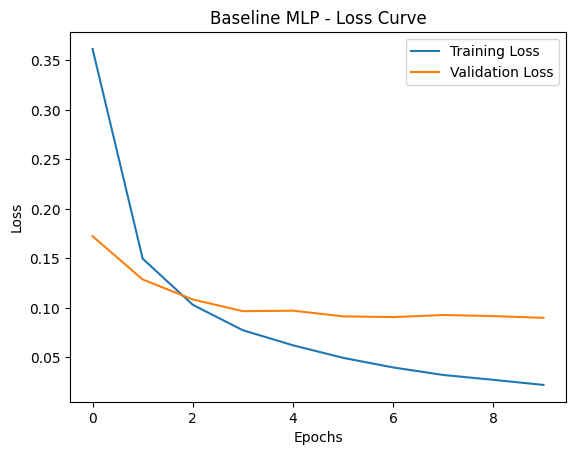

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build MLP Model (No Regularization)
# -----------------------------
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# -----------------------------
# Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Baseline MLP - Loss Curve')
plt.show()


***DROPOUT ***

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7465 - loss: 0.7979 - val_accuracy: 0.9273 - val_loss: 0.2471
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8852 - loss: 0.3984 - val_accuracy: 0.9445 - val_loss: 0.1886
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9084 - loss: 0.3260 - val_accuracy: 0.9522 - val_loss: 0.1657
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9193 - loss: 0.2892 - val_accuracy: 0.9564 - val_loss: 0.1503
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9275 - loss: 0.2570 - val_accuracy: 0.9612 - val_loss: 0.1354
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9325 - loss: 0.2375 - val_accuracy: 0.9641 - val_loss: 0.1283
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9360 - loss: 0.2287 - val_accuracy: 0.9652 - val_loss: 0.1206
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9400 - loss: 0.2112 - val_accuracy: 0.

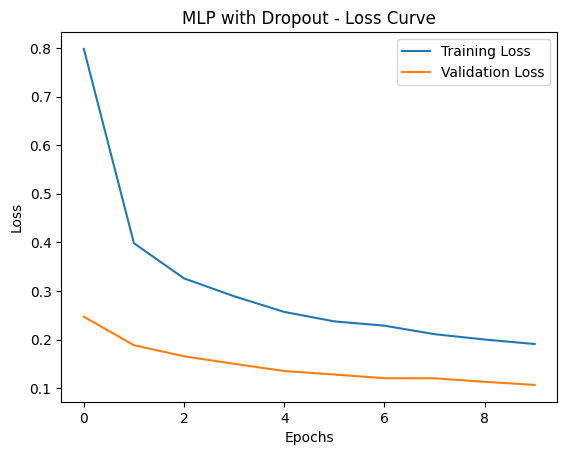

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build MLP Model (With Dropout)
# -----------------------------
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))          # Dropout layer

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))          # Dropout layer

model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# -----------------------------
# Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP with Dropout - Loss Curve')
plt.show()


***L2 REGULARIZATION***

Epoch 1/10


c:\Users\prneh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8925 - loss: 0.5793 - val_accuracy: 0.9428 - val_loss: 0.3644
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9511 - loss: 0.3241 - val_accuracy: 0.9582 - val_loss: 0.2878
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9623 - loss: 0.2640 - val_accuracy: 0.9635 - val_loss: 0.2513
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9673 - loss: 0.2327 - val_accuracy: 0.9641 - val_loss: 0.2346
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9709 - loss: 0.2113 - val_accuracy: 0.9696 - val_loss: 0.2138
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9741 - loss: 0.1947 - val_accuracy: 0.9683 - val_loss: 0.2119
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9750 - loss: 0.1854 - val_accuracy: 0.9730 - val_loss: 0.1910
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9773 - loss: 0.1747 - val_accuracy: 0.9717 - val_

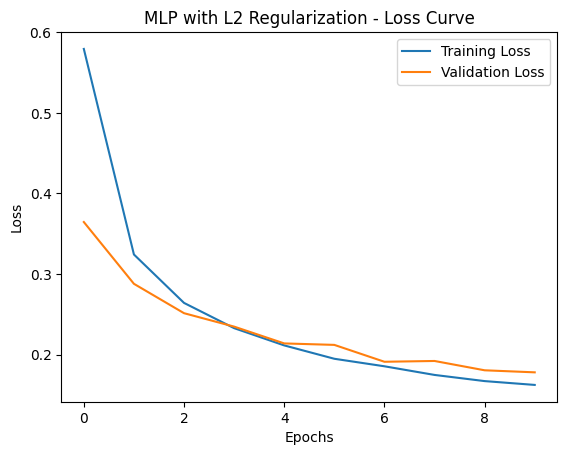

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build MLP Model (With L2 Regularization)
# -----------------------------
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))

model.add(Dense(128, activation='relu',
                kernel_regularizer=l2(0.001)))   # L2 applied

model.add(Dense(64, activation='relu',
                kernel_regularizer=l2(0.001)))   # L2 applied

model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# -----------------------------
# Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP with L2 Regularization - Loss Curve')
plt.show()


***BATCH NORMALIZATION***

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9101 - loss: 0.3367 - val_accuracy: 0.9538 - val_loss: 0.1639
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9667 - loss: 0.1177 - val_accuracy: 0.9621 - val_loss: 0.1282
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9788 - loss: 0.0740 - val_accuracy: 0.9674 - val_loss: 0.1046
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9845 - loss: 0.0537 - val_accuracy: 0.9737 - val_loss: 0.0860
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9884 - loss: 0.0395 - val_accuracy: 0.9722 - val_loss: 0.0922
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9905 - loss: 0.0315 - val_accuracy: 0.9707 - val_loss: 0.0992
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9925 - loss: 0.0247 - val_accuracy: 0.9736 - val_loss: 0.0940
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9935 - loss: 0.0212 - val_accuracy: 0.

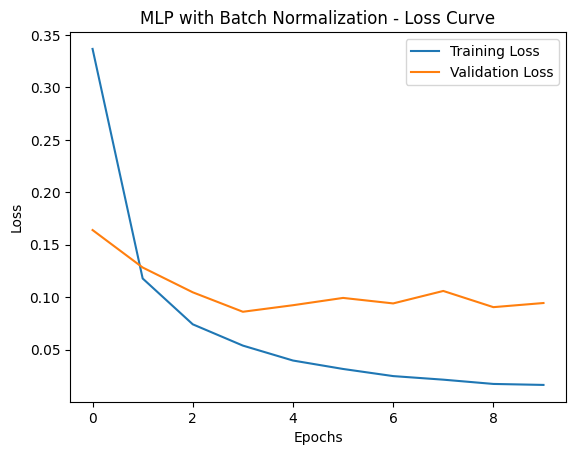

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build MLP Model (With Batch Normalization)
# -----------------------------
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))

model.add(Dense(128))
model.add(BatchNormalization())   # Batch Norm
model.add(tf.keras.layers.Activation('relu'))

model.add(Dense(64))
model.add(BatchNormalization())   # Batch Norm
model.add(tf.keras.layers.Activation('relu'))

model.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# -----------------------------
# Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

# -----------------------------
# Plot Loss Curve
# -----------------------------
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('MLP with Batch Normalization - Loss Curve')
plt.show()
